# Poisson equation on $(0,1)$: finite differences and finite elements
Solve $-u''=f$ with $u(0)=u(1)=0$. Here $N$ is the number of interior nodes and $h=1/(N+1)$. The supplied exact solutions determine $f$; the original $-f$ labels had the opposite sign. For problem 4, use $|x-1/2|^3-1/8$ to satisfy the boundary conditions.


In [1]:
N_VALUES = [15, 31, 63, 127]
import matplotlib.pyplot as plt
import numpy as np


def solve_poisson(n, rhs):
    """Solve (2u_i-u_{i-1}-u_{i+1})/h**2 = f(x_i)."""
    # N interior nodes; homogeneous boundary values are built into the system.
    h = 1.0 / (n + 1)
    x = h * np.arange(1, n + 1)
    diagonal = np.full(n, 2.0)
    upper = np.full(n - 1, -1.0)
    b = h * h * rhs(x)

    # Thomas algorithm for the tridiagonal matrix; boundary values are zero.
    for i in range(1, n):
        factor = -1.0 / diagonal[i - 1]
        diagonal[i] -= factor * upper[i - 1]
        b[i] -= factor * b[i - 1]
    u = np.empty(n)
    u[-1] = b[-1] / diagonal[-1]
    for i in range(n - 2, -1, -1):
        u[i] = (b[i] - upper[i] * u[i + 1]) / diagonal[i]
    return x, u


CASES = {
    "quadratic": (
        lambda x: x * (1 - x),
        lambda x: np.full_like(x, 2.0),
        lambda h: 0.0,
    ),
    "quartic": (
        lambda x: x**4 - x,
        lambda x: -12 * x**2,
        lambda h: h**2 / 4,
    ),
    "cosine": (
        lambda x: 1 - np.cos(2 * np.pi * x),
        lambda x: -4 * np.pi**2 * np.cos(2 * np.pi * x),
        lambda h: np.pi**4 * h**2 / 6,
    ),
    "absolute_cubic": (
        lambda x: np.abs(x - 0.5) ** 3 - 0.125,
        lambda x: -6 * np.abs(x - 0.5),
        lambda h: h**2 / 2,
    ),
}


def evaluate_case(name, mesh_sizes):
    """Return (case, N, h, maximum error, observed rate, bound) rows."""
    exact, rhs, bound = CASES[name]
    rows = []
    previous = None
    for n in sorted(mesh_sizes):
        h = 1 / (n + 1)
        x, numeric = solve_poisson(n, rhs)
        error = float(np.max(np.abs(numeric - exact(x))))
        # Compare consecutive meshes: E(h) approximately C*h**rate.
        rate = (np.log(previous[1] / error) / np.log(previous[0] / h)
                if name != "quadratic" and previous is not None
                and error > 0 and previous[1] > 0 else float("nan"))
        predicted = bound(h) if name != "absolute_cubic" or n % 2 else float("nan")
        rows.append((name, n, h, error, rate, predicted))
        previous = (h, error)
    return rows


FD_BOUND_FORMULAS = {
    "quadratic": "0 h²",
    "quartic": "(1/4) h²",
    "cosine": "(π⁴/6) h²",
    "absolute_cubic": "(1/2) h²",
}


def print_table(rows, title):
    print(f"\n{title}\n{'=' * len(title)}")
    print(f"{'Case':<17} {'N':>5} {'h':>11} {'L_inf error':>14} {'Rate':>9} {'Bound formula':>16} {'Bound value':>14}")
    print("-" * 96)
    for name, n, h, error, rate, bound in rows:
        rate_text = f"{rate:.4f}" if np.isfinite(rate) else "—"
        bound_text = f"{bound:.6e}" if np.isfinite(bound) else "—"
        print(f"{name:<17} {n:>5} {h:>11.6f} {error:>14.6e} "
              f"{rate_text:>9} {FD_BOUND_FORMULAS[name]:>16} {bound_text:>14}")


def plot_errors(rows, output=None):
    """Display the plot in a notebook, or save it when output is given."""
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in CASES:
        if name == "quadratic":
            continue  # Its discretization error is exactly zero.
        points = [(h, error) for case, _, h, error, _, _ in rows if case == name]
        ax.loglog(*zip(*points), marker="o", label=name)
    hs = np.array(sorted({h for _, _, h, _, _, _ in rows}))
    ax.loglog(hs, hs**2, "k--", label=r"reference $h^2$")
    ax.set(xlabel="mesh spacing h", ylabel=r"maximum error $\|u_h-u\|_\infty$",
           title="Three-point Poisson finite-difference error")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if output is None:
        plt.show()
    else:
        fig.savefig(output, dpi=180)
        plt.close(fig)



## Three-point finite differences
At each interior node, $(2U_i-U_{i-1}-U_{i+1})/h^2=f(x_i)$, with $U_0=U_{N+1}=0$. This gives a tridiagonal system. The centered stencil has truncation error at most $h^2\|u^{(4)}\|_\infty/12$; stability gives $\|u-U\|_\infty\le h^2\|u^{(4)}\|_\infty/96$. Thus the bounds are $0$, $h^2/4$, and $\pi^4h^2/6$ for problems 1–3. For problem 4, the requested odd meshes place $x=1/2$ at a node and the grid error is exactly $h^2/2$.


## Problem 1: $u(x)=x(1-x)$, $f(x)=2$

In [2]:
problem_1 = evaluate_case('quadratic', N_VALUES)
print_table(problem_1, 'Problem 1: quadratic')


Problem 1: quadratic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quadratic            15    0.062500   2.775558e-17         —             0 h²   0.000000e+00
quadratic            31    0.031250   7.771561e-16         —             0 h²   0.000000e+00
quadratic            63    0.015625   2.386980e-15         —             0 h²   0.000000e+00
quadratic           127    0.007812   2.386980e-15         —             0 h²   0.000000e+00


## Problem 2: $u(x)=x^4-x$, $f(x)=-12x^2$

In [3]:
problem_2 = evaluate_case('quartic', N_VALUES)
print_table(problem_2, 'Problem 2: quartic')


Problem 2: quartic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quartic              15    0.062500   9.765625e-04         —         (1/4) h²   9.765625e-04
quartic              31    0.031250   2.441406e-04    2.0000         (1/4) h²   2.441406e-04
quartic              63    0.015625   6.103516e-05    2.0000         (1/4) h²   6.103516e-05
quartic             127    0.007812   1.525879e-05    2.0000         (1/4) h²   1.525879e-05


## Problem 3: $u(x)=1-\cos(2\pi x)$, $f(x)=-4\pi^2\cos(2\pi x)$

In [4]:
problem_3 = evaluate_case('cosine', N_VALUES)
print_table(problem_3, 'Problem 3: cosine')


Problem 3: cosine
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
cosine               15    0.062500   2.590149e-02         —        (π⁴/6) h²   6.341738e-02
cosine               31    0.031250   6.437929e-03    2.0084        (π⁴/6) h²   1.585434e-02
cosine               63    0.015625   1.607155e-03    2.0021        (π⁴/6) h²   3.963586e-03
cosine              127    0.007812   4.016436e-04    2.0005        (π⁴/6) h²   9.908965e-04


## Problem 4: $u(x)=|x-1/2|^3-1/8$, $f(x)=-6|x-1/2|$

In [5]:
problem_4 = evaluate_case('absolute_cubic', N_VALUES)
print_table(problem_4, 'Problem 4: absolute cubic')


Problem 4: absolute cubic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
absolute_cubic       15    0.062500   1.953125e-03         —         (1/2) h²   1.953125e-03
absolute_cubic       31    0.031250   4.882813e-04    2.0000         (1/2) h²   4.882812e-04
absolute_cubic       63    0.015625   1.220703e-04    2.0000         (1/2) h²   1.220703e-04
absolute_cubic      127    0.007812   3.051758e-05    2.0000         (1/2) h²   3.051758e-05


## Finite difference summary and error graph


Final table: all problems
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quadratic            15    0.062500   2.775558e-17         —             0 h²   0.000000e+00
quadratic            31    0.031250   7.771561e-16         —             0 h²   0.000000e+00
quadratic            63    0.015625   2.386980e-15         —             0 h²   0.000000e+00
quadratic           127    0.007812   2.386980e-15         —             0 h²   0.000000e+00
quartic              15    0.062500   9.765625e-04         —         (1/4) h²   9.765625e-04
quartic              31    0.031250   2.441406e-04    2.0000         (1/4) h²   2.441406e-04
quartic              63    0.015625   6.103516e-05    2.0000         (1/4) h²   6.103516e-05
quartic             127    0.007812   1.525879e-05    2.0000         (1/4) h²   1.525879e-05
cosine               15    0.062500   2

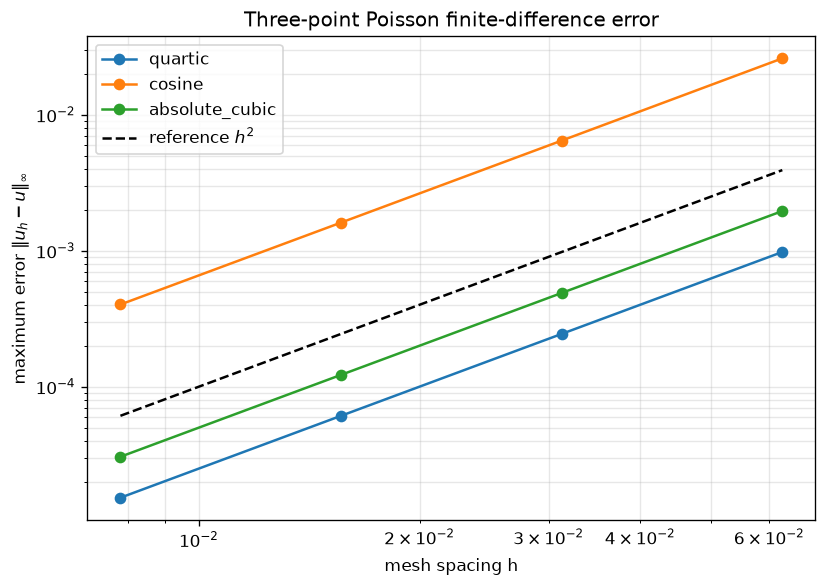

In [6]:
all_results = problem_1 + problem_2 + problem_3 + problem_4
print_table(all_results, 'Final table: all problems')
plot_errors(all_results)

## Piecewise-linear finite elements
Weak form: find $u_h$ in the space of continuous piecewise-linear functions vanishing at both ends such that $\int_0^1u_h'v_h'\,dx=\int_0^1fv_h\,dx$ for every test function $v_h$. Hat functions give stiffness entries $2/h$ on the diagonal and $-1/h$ beside it. The load integrals use eight-point Gauss quadrature; an element crossing $x=1/2$ is split there.
With exact load integration in this 1D constant-coefficient problem, FEM nodal values equal the exact nodal values. Therefore $\|u-u_h\|_\infty\le h^2\|u''\|_\infty/8$. The bounds for problems 1–4 are $h^2/4$, $3h^2/2$, $\pi^2h^2/2$, and $3h^2/8$. The reported maximum error samples each element at 1001 points, so it approximates the continuous norm.


In [7]:
# Piecewise-linear finite elements on the same uniform meshes.
# Split an element at x=1/2 when it contains the cusp in problem 4.
GAUSS_X, GAUSS_W = np.polynomial.legendre.leggauss(8)
FEM_BOUND_COEFFICIENTS = {
    "quadratic": 1/4,
    "quartic": 3/2,
    "cosine": np.pi**2 / 2,
    "absolute_cubic": 3/8,
}
FEM_BOUND_FORMULAS = {
    "quadratic": "(1/4) h²",
    "quartic": "(3/2) h²",
    "cosine": "(π²/2) h²",
    "absolute_cubic": "(3/8) h²",
}


def solve_fem(n, rhs):
    h = 1.0 / (n + 1)
    nodes = np.linspace(0.0, 1.0, n + 2)
    # K_ij = integral(phi_i prime * phi_j prime).
    stiffness = np.diag(np.full(n, 2.0 / h))
    stiffness += np.diag(np.full(n - 1, -1.0 / h), 1)
    stiffness += np.diag(np.full(n - 1, -1.0 / h), -1)
    # b_i = integral(f * phi_i), assembled element by element.
    load = np.zeros(n)
    for element in range(n + 1):
        left, right = nodes[element:element + 2]
        cuts = [left, right]
        if left < 0.5 < right:
            cuts = [left, 0.5, right]
        for a, b in zip(cuts[:-1], cuts[1:]):
            quadrature_x = (a + b) / 2 + (b - a) * GAUSS_X / 2
            quadrature_w = (b - a) * GAUSS_W / 2
            weighted_f = quadrature_w * rhs(quadrature_x)
            if element > 0:
                load[element - 1] += np.sum(weighted_f * (right - quadrature_x) / h)
            if element < n:
                load[element] += np.sum(weighted_f * (quadrature_x - left) / h)
    interior_solution = np.linalg.solve(stiffness, load)
    return nodes, np.r_[0.0, interior_solution, 0.0]


def evaluate_fem_case(name, mesh_sizes):
    exact, rhs, _ = CASES[name]
    rows = []
    previous = None
    for n in sorted(mesh_sizes):
        nodes, nodal_solution = solve_fem(n, rhs)
        h = 1.0 / (n + 1)
        # Sample the continuous FEM error within every element.
        t = np.linspace(0.0, 1.0, 1001)
        sample_x = nodes[:-1, None] + h * t[None, :]
        sample_u = nodal_solution[:-1, None] * (1 - t) + nodal_solution[1:, None] * t
        error = float(np.max(np.abs(exact(sample_x) - sample_u)))
        rate = (np.log(previous[1] / error) / np.log(previous[0] / h)
                if previous is not None and error > 0 and previous[1] > 0
                else float("nan"))
        bound = FEM_BOUND_COEFFICIENTS[name] * h**2
        rows.append((name, n, h, error, rate, bound))
        previous = (h, error)
    return rows


def print_fem_table(rows, title):
    print(f"\n{title}\n{'=' * len(title)}")
    print(f"{'Case':<17} {'N':>5} {'h':>11} {'L_inf error':>14} {'Rate':>9} {'Bound formula':>16} {'Bound value':>14}")
    print("-" * 96)
    for name, n, h, error, rate, bound in rows:
        rate_text = f"{rate:.4f}" if np.isfinite(rate) else "—"
        print(f"{name:<17} {n:>5} {h:>11.6f} {error:>14.6e} "
              f"{rate_text:>9} {FEM_BOUND_FORMULAS[name]:>16} {bound:>14.6e}")


### FEM problem 1: $u(x)=x(1-x)$

In [8]:
fem_1 = evaluate_fem_case('quadratic', N_VALUES)
print_fem_table(fem_1, 'FEM problem 1: quadratic')



FEM problem 1: quadratic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quadratic            15    0.062500   9.765625e-04         —         (1/4) h²   9.765625e-04
quadratic            31    0.031250   2.441406e-04    2.0000         (1/4) h²   2.441406e-04
quadratic            63    0.015625   6.103516e-05    2.0000         (1/4) h²   6.103516e-05
quadratic           127    0.007812   1.525879e-05    2.0000         (1/4) h²   1.525879e-05


### FEM problem 2: $u(x)=x^4-x$

In [9]:
fem_2 = evaluate_fem_case('quartic', N_VALUES)
print_fem_table(fem_2, 'FEM problem 2: quartic')



FEM problem 2: quartic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quartic              15    0.062500   5.500472e-03         —         (3/2) h²   5.859375e-03
quartic              31    0.031250   1.419524e-03    1.9541         (3/2) h²   1.464844e-03
quartic              63    0.015625   3.605173e-04    1.9773         (3/2) h²   3.662109e-04
quartic             127    0.007812   9.083922e-05    1.9887         (3/2) h²   9.155273e-05


### FEM problem 3: $u(x)=1-\cos(2\pi x)$

In [10]:
fem_3 = evaluate_fem_case('cosine', N_VALUES)
print_fem_table(fem_3, 'FEM problem 3: cosine')



FEM problem 3: cosine
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
cosine               15    0.062500   1.884631e-02         —        (π²/2) h²   1.927657e-02
cosine               31    0.031250   4.792098e-03    1.9756        (π²/2) h²   4.819143e-03
cosine               63    0.015625   1.203093e-03    1.9939        (π²/2) h²   1.204786e-03
cosine              127    0.007812   3.010906e-04    1.9985        (π²/2) h²   3.011964e-04


### FEM problem 4: $u(x)=|x-1/2|^3-1/8$

In [11]:
fem_4 = evaluate_fem_case('absolute_cubic', N_VALUES)
print_fem_table(fem_4, 'FEM problem 4: absolute cubic')



FEM problem 4: absolute cubic
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
absolute_cubic       15    0.062500   1.373459e-03         —         (3/8) h²   1.464844e-03
absolute_cubic       31    0.031250   3.547770e-04    1.9528         (3/8) h²   3.662109e-04
absolute_cubic       63    0.015625   9.012282e-05    1.9769         (3/8) h²   9.155273e-05
absolute_cubic      127    0.007812   2.270940e-05    1.9886         (3/8) h²   2.288818e-05


## Final finite-difference and finite-element tables and graph
The rate is $\log(E_{old}/E_{new})/\log(h_{old}/h_{new})$; a rate near 2 indicates $O(h^2)$ convergence. Finite-difference errors use grid nodes, while finite-element errors use the continuous piecewise-linear solution. Each table gives the formula $C h^2$ and its numerical value.


In [12]:
fem_results = fem_1 + fem_2 + fem_3 + fem_4
print_table(all_results, 'Final FD table: all problems')
print_fem_table(fem_results, 'Final FEM table: all problems')



Final FD table: all problems
Case                  N           h    L_inf error      Rate    Bound formula    Bound value
------------------------------------------------------------------------------------------------
quadratic            15    0.062500   2.775558e-17         —             0 h²   0.000000e+00
quadratic            31    0.031250   7.771561e-16         —             0 h²   0.000000e+00
quadratic            63    0.015625   2.386980e-15         —             0 h²   0.000000e+00
quadratic           127    0.007812   2.386980e-15         —             0 h²   0.000000e+00
quartic              15    0.062500   9.765625e-04         —         (1/4) h²   9.765625e-04
quartic              31    0.031250   2.441406e-04    2.0000         (1/4) h²   2.441406e-04
quartic              63    0.015625   6.103516e-05    2.0000         (1/4) h²   6.103516e-05
quartic             127    0.007812   1.525879e-05    2.0000         (1/4) h²   1.525879e-05
cosine               15    0.062500 

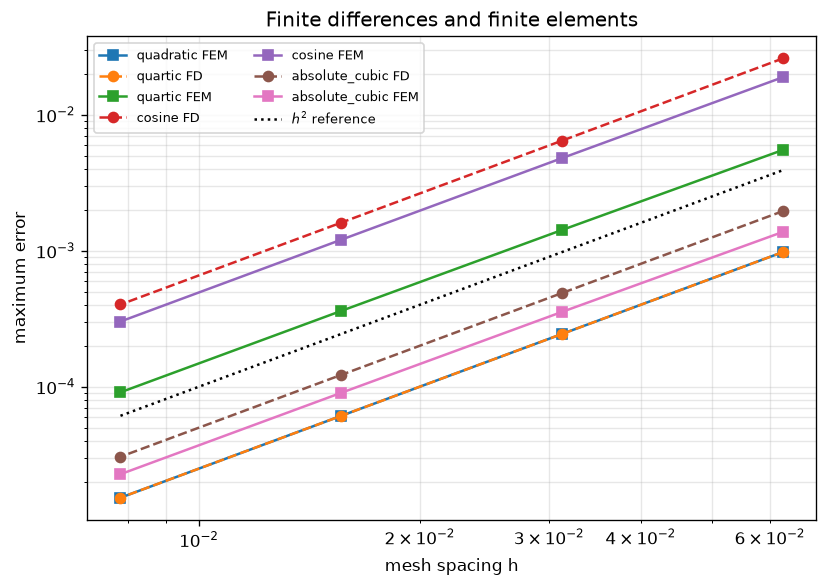

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in CASES:
    fd_points = [(h, error) for case, _, h, error, _, _ in all_results if case == name]
    fem_points = [(h, error) for case, _, h, error, _, _ in fem_results if case == name]
    if name != "quadratic":
        ax.loglog(*zip(*fd_points), "o--", label=f"{name} FD")
    ax.loglog(*zip(*fem_points), "s-", label=f"{name} FEM")
hs = sorted({h for _, _, h, _, _, _ in fem_results})
ax.loglog(hs, np.array(hs)**2, "k:", label="$h^2$ reference")
ax.set(xlabel="mesh spacing h", ylabel="maximum error", title="Finite differences and finite elements")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
